### Imports

In [43]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import joblib

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.utils.class_weight import compute_class_weight

from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint

### LOAD DATA

In [44]:
df = pd.read_csv(r'../data/bug_reports_clean.csv')
print(df.shape)
print(df.isnull().sum())
df.head()

(16512, 3)
text          0
severity      0
clean_text    2
dtype: int64


,text,severity,clean_text
0,Typo in error message,trivial,typo in error message
1,cookies are incorrectly detainted when logging...,trivial,cookies are incorrectly detainted when logging...
2,DERIVE_GROUPS_TABLES_ALREADY_LOCKED is ignored...,critical,derive groups tables already locked is ignored...
3,trivial UI changes for 2.20 (Selenium compat),trivial,trivial ui changes for 2 20 selenium compat
4,admin/classifications/select.html.tmpl has a l...,trivial,admin classifications select html tmpl has a l...


In [45]:
df = df.dropna()
df.isnull().sum()

text          0
severity      0
clean_text    0
dtype: int64

### Features and Target

In [46]:
X = df['clean_text']
y = df['severity']

### Label Encoding

In [47]:
label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(y)
label_encoder.classes_

array(['blocker', 'critical', 'major', 'minor', 'trivial'], dtype=object)

In [48]:
# save encodings 
joblib.dump(label_encoder, "..\models\label_encoder.pkl")
print("Saved")

Saved


<>:2: SyntaxWarning: invalid escape sequence '\m'
<>:2: SyntaxWarning: invalid escape sequence '\m'
C:\Users\ASUS\AppData\Local\Temp\ipykernel_2952\1687576610.py:2: SyntaxWarning: invalid escape sequence '\m'
  joblib.dump(label_encoder, "..\models\label_encoder.pkl")


In [49]:
tfidf = TfidfVectorizer(
    max_features=10000,
    ngram_range=(1, 2),
    min_df=2,
    max_df=0.95
)
X_tfidf = tfidf.fit_transform(X)
X_tfidf.shape

(16510, 10000)

### Train Test Split

In [50]:
X_train, X_test, y_train, y_test = train_test_split(X_tfidf, y_encoded, test_size=0.2, random_state=42, stratify=y_encoded)
print(X_train.shape)
print(X_test.shape)

(13208, 10000)
(3302, 10000)


In [51]:
classes = np.unique(y_train)
weights = compute_class_weight(
    class_weight="balanced",
    classes=classes,
    y=y_train
)

What `compute_class_weight()` Does

It gives higher importance to rare classes and lower importance to common classes.

In [52]:
class_weights = {
    i: weights[i]  for i in range(len(weights))
}

print("Class Weights:")
print(class_weights)

Class Weights:
{0: np.float64(4.1339593114241), 1: np.float64(0.5563605728727885), 2: np.float64(0.7221432476763259), 3: np.float64(1.057062825130052), 4: np.float64(1.5875)}


### Convert SPARSE -> DENSE

In [53]:
X_train[0]

<Compressed Sparse Row sparse matrix of dtype 'float64'
	with 5 stored elements and shape (1, 10000)>

In [54]:
X_train = X_train.toarray().astype(np.float32)
X_test = X_test.toarray().astype(np.float32)

In [55]:
X_train

array([[0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       ...,
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.]], shape=(13208, 10000), dtype=float32)

###  Build DNN Model

In [56]:
print("Building Model")
model = Sequential([
    tf.keras.layers.Input(shape=(X_train.shape[1],)),
    tf.keras.layers.Dense(500, activation='relu'),
    tf.keras.layers.Dropout(0.4),
    tf.keras.layers.Dense(250, activation='relu'),
    tf.keras.layers.Dropout(0.3),
    tf.keras.layers.Dense(100, activation='relu'),
    tf.keras.layers.Dropout(0.2),
    tf.keras.layers.Dense(5, activation='softmax'),
])

Building Model


In [57]:
model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)
model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_9 (Dense)                 │ (None, 500)            │     5,000,500 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_7 (Dropout)             │ (None, 500)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 250)            │       125,250 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_8 (Dropout)             │ (None, 250)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 100)            │        25,100 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_9 (Dropout)             │ (None, 100)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_12 (Dense)                │ (None, 5)              │           505 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 5,151,355 (19.65 MB)

 Trainable params: 5,151,355 (19.65 MB)

 Non-trainable params: 0 (0.00 B)

In [58]:
earlystopping = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True, verbose=1)
checkpoint = ModelCheckpoint('../models/bug_severity_dnn.keras', monitor='val_accuracy', save_best_only=True, verbose=1)

In [59]:
history = model.fit(
    X_train,
    y_train,
    validation_split=0.1,
    epochs=20,
    batch_size=64,
    class_weight=class_weights,
    callbacks = [earlystopping, checkpoint],
    verbose=1
)

Epoch 1/20
186/186 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step - accuracy: 0.3877 - loss: 1.4568
Epoch 1: val_accuracy improved from None to 0.61696, saving model to ../models/bug_severity_dnn.keras

Epoch 1: finished saving model to ../models/bug_severity_dnn.keras
186/186 ━━━━━━━━━━━━━━━━━━━━ 12s 57ms/step - accuracy: 0.4852 - loss: 1.2948 - val_accuracy: 0.6170 - val_loss: 0.9935
Epoch 2/20
186/186 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step - accuracy: 0.6939 - loss: 0.8373
Epoch 2: val_accuracy did not improve from 0.61696
186/186 ━━━━━━━━━━━━━━━━━━━━ 8s 42ms/step - accuracy: 0.6797 - loss: 0.8447 - val_accuracy: 0.6094 - val_loss: 0.9939
Epoch 3/20
185/186 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step - accuracy: 0.8373 - loss: 0.4577
Epoch 3: val_accuracy did not improve from 0.61696
186/186 ━━━━━━━━━━━━━━━━━━━━ 9s 50ms/step - accuracy: 0.8218 - loss: 0.4844 - val_accuracy: 0.5950 - val_loss: 1.1009
Epoch 4/20
185/186 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step - accuracy: 0.9147 - loss: 0.2339
Epoch 4: val_accuracy did

### Evaluation

In [60]:
loss, accuracy = model.evaluate(X_test, y_test, verbose=0)
print(f'Loss : {loss}')
print(f'Accuracy : {accuracy}')

Loss : 1.021319031715393
Accuracy : 0.5893397927284241


In [61]:
pred_proba = model.predict(X_test)
y_pred = np.argmax(pred_proba, axis=1)

104/104 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step


### Classification Report

In [62]:
print(classification_report(y_test, y_pred, target_names=label_encoder.classes_))

              precision    recall  f1-score   support

     blocker       0.60      0.34      0.43       159
    critical       0.93      0.74      0.83      1187
       major       0.55      0.54      0.54       915
       minor       0.35      0.36      0.35       625
     trivial       0.40      0.71      0.51       416

    accuracy                           0.59      3302
   macro avg       0.57      0.54      0.53      3302
weighted avg       0.63      0.59      0.60      3302



### Confusion Matrix

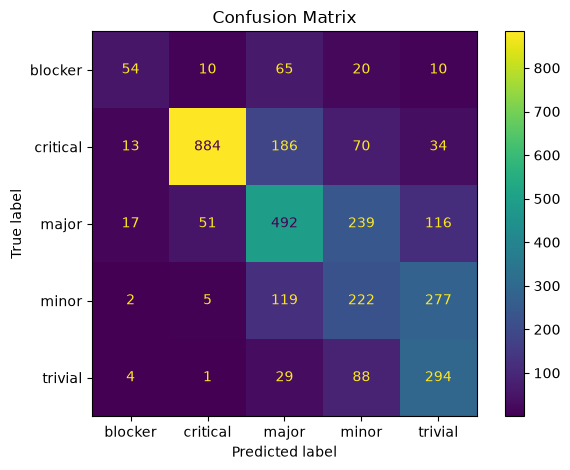

In [63]:
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay( confusion_matrix=cm, display_labels=label_encoder.classes_)
disp.plot()
plt.title("Confusion Matrix")
plt.tight_layout()
plt.show()

### Traning Curves

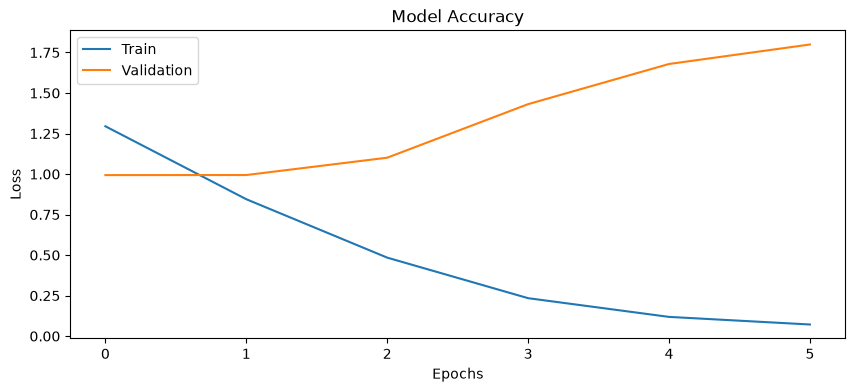

In [64]:
plt.figure(figsize=(10,4))
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title("Model Accuracy")
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend(['Train','Validation'])

From above Graph we know that are model is `Overfitted`

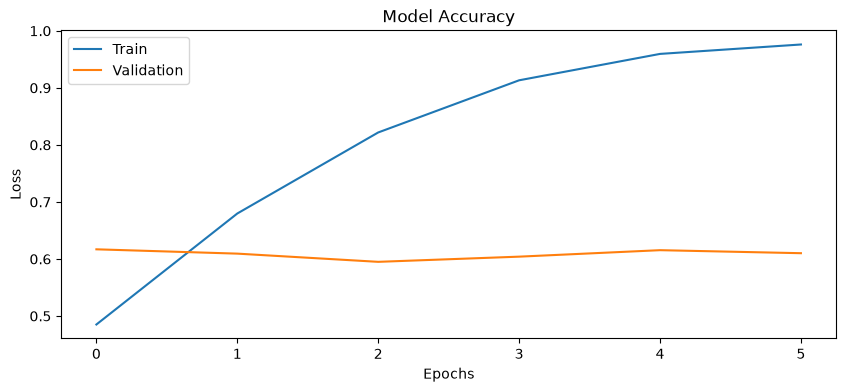

In [65]:
plt.figure(figsize=(10,4))
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title("Model Accuracy")
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend(['Train','Validation'])